## Practical Work 1

For this practical work, the student will have to develop a Python program that is able to implement the gradient descent in order to achieve the linear regression of a set of datapoints.

#### Import numpy, matplotlib.pyplot and make it inline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from gradient_descent import (add_bias, standardize, cost_function,
                              gradient_descent, r2_score)

#### Read RegData csv file into numpy array  (check your data)
##### Data source
https://college.cengage.com/mathematics/brase/understandable_statistics/7e/students/datasets/slr/frames/frame.html


In [ ]:
# Files live next to the notebook (no Google Drive needed)
data = np.genfromtxt("RegData.csv", delimiter=",")

#### Explore your data

In [ ]:
print(np.shape(data))
print(data)

(13, 2)
[[2.9000001  4.        ]
 [6.69999981 7.4000001 ]
 [4.9000001  5.        ]
 [7.9000001  7.19999981]
 [9.80000019 7.9000001 ]
 [6.9000001  6.0999999 ]
 [6.0999999  6.        ]
 [6.19999981 5.80000019]
 [6.         5.19999981]
 [5.0999999  4.19999981]
 [4.69999981 4.        ]
 [4.4000001  4.4000001 ]
 [5.80000019 5.19999981]]


#### Define variables X and y. Assign first column data to X and second column to y
<b>Note:</b> X is the independent variable (input to LR model) and y is the dependent variable (output)

In [ ]:
X = data[ : , 0]
Y = data[: , 1]


#### Explore your data

In [ ]:
print(X)


[2.9000001  6.69999981 4.9000001  7.9000001  9.80000019 6.9000001
 6.0999999  6.19999981 6.         5.0999999  4.69999981 4.4000001
 5.80000019]


In [ ]:
print(Y)

[4.         7.4000001  5.         7.19999981 7.9000001  6.0999999
 6.         5.80000019 5.19999981 4.19999981 4.         4.4000001
 5.19999981]


#### Plot the original data (scatter plot of X,y)

In [ ]:
plt.plot(X, Y, "*")
plt.xlabel("X"); plt.ylabel("y")
plt.show()

## LR Full Implementation

### Step1: Initialize parameters (theta_0 & theta_1) with random value or simply zero. Also choose the Learning rate. 

![image.png](attachment:image.png)

In [ ]:
theta_0 = 0 
theta_1 = 0
alpha = .005

### Step2: Use (theta_0 & theta_1) to predict the output h(x)= theta_0 + theta_1 * x.![image.png](attachment:image.png)
#### Note: you will need to iterate through all data points

In [ ]:
h = theta_0 + theta_1 * X
print(h)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Step3: Calculate Cost function 𝑱(theta_0,theta_1 ).![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)

In [ ]:
m = len(X)
cost = (1 / (2 * m)) * np.sum(np.square(h - Y))  # J = 1/(2m) * sum((h-y)^2)
print(cost)

### Step4: Calculate the gradient.![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)

In [ ]:
diff_theta_0 = (1/m) * np.sum( h - Y ) 
diff_theta_1 = (1/m) * np.sum( (h - Y) * X )
print(diff_theta_0)
print(diff_theta_1)

-5.569230739769231
-35.043846043215375


### Step5: Update the parameters (simultaneously).![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)

In [ ]:
theta_0 = theta_0 - alpha * diff_theta_0
theta_1 = theta_1 - alpha * diff_theta_1
print(theta_0)
print(theta_1)

0.027846153698846157
0.17521923021607688


### Step6: Repeat from 2 to 5 until converge to the minimum or achieve maximum iterations.![image.png](attachment:image.png)

In [ ]:
# Reset parameters so this cell is re-runnable
theta_0, theta_1, alpha = 0.0, 0.0, 0.005
tol = 1e-6                      # stop when the *gradient* norm is this small
cost_list, theta_0_list, theta_1_list = [], [], []
for i in range(100000):
    h = theta_0 + theta_1 * X                      # step 2: hypothesis
    cost_list.append((1 / (2 * m)) * np.sum((h - Y) ** 2))   # step 3: cost
    diff_theta_0 = (1 / m) * np.sum(h - Y)         # step 4: gradient
    diff_theta_1 = (1 / m) * np.sum((h - Y) * X)
    Gradient = np.hypot(diff_theta_0, diff_theta_1)
    if Gradient < tol:                             # converged
        break
    theta_0 -= alpha * diff_theta_0                # step 5: simultaneous update
    theta_1 -= alpha * diff_theta_1
    theta_0_list.append(theta_0)
    theta_1_list.append(theta_1)
itter_list = list(range(len(cost_list)))
print("iterations:", i, " theta_0:", theta_0, " theta_1:", theta_1, " |grad|:", Gradient)

#### Predict y values using the LR equation
##### h(x)= theta_0 + theta_1 * x

In [ ]:
h = theta_0 + theta_1 * X
print(h)

[3.27193867 6.10266916 4.76179694 6.99658434 8.41194976 6.2516552
 5.65571176 5.7302046  5.58121891 4.91078262 4.6128109  4.38933237
 5.43223323]


#### Plot  LR equation output (fitted line) with the original data (scatter plot of X,y)

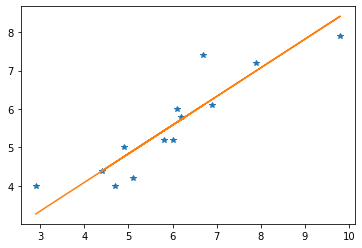

In [ ]:
plt.plot(X,Y, "*")
plt.plot(X,h)
plt.show()

#### Use R2 score to evaluate LR equation output
![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)
![image-3.png](attachment:image-3.png)
https://en.wikipedia.org/wiki/Coefficient_of_determination

In [ ]:
r2_score(Y, h)

## Plot loss function


In [ ]:
plt.plot(itter_list, cost_list)
plt.xlabel("Iteration"); plt.ylabel("Cost J")
plt.show()

### Plot loss vs. iterations

## Multivariate LR

#### Read MultipleLR csv file into numpy array  (check your data)
##### Data source
https://college.cengage.com/mathematics/brase/understandable_statistics/7e/students/datasets/slr/frames/frame.html


In [ ]:
multi_data = np.genfromtxt("MultipleLR.csv", delimiter=",")

In [ ]:
np.shape(multi_data)
multi_data

array([[ 73.,  80.,  75., 152.],
       [ 93.,  88.,  93., 185.],
       [ 89.,  91.,  90., 180.],
       [ 96.,  98., 100., 196.],
       [ 73.,  66.,  70., 142.],
       [ 53.,  46.,  55., 101.],
       [ 69.,  74.,  77., 149.],
       [ 47.,  56.,  60., 115.],
       [ 87.,  79.,  90., 175.],
       [ 79.,  70.,  88., 164.],
       [ 69.,  70.,  73., 141.],
       [ 70.,  65.,  74., 141.],
       [ 93.,  95.,  91., 184.],
       [ 79.,  80.,  73., 152.],
       [ 70.,  73.,  78., 148.],
       [ 93.,  89.,  96., 192.],
       [ 78.,  75.,  68., 147.],
       [ 81.,  90.,  93., 183.],
       [ 88.,  92.,  86., 177.],
       [ 78.,  83.,  77., 159.],
       [ 82.,  86.,  90., 177.],
       [ 86.,  82.,  89., 175.],
       [ 78.,  83.,  85., 175.],
       [ 76.,  83.,  71., 149.],
       [ 96.,  93.,  95., 192.]])

In [ ]:
X = multi_data[: , : -1]
Y = multi_data[: , -1 ]
print(np.shape(X))
print(np.shape(Y))
print(X)
print(Y)


(25, 3)
(25,)
[[ 73.  80.  75.]
 [ 93.  88.  93.]
 [ 89.  91.  90.]
 [ 96.  98. 100.]
 [ 73.  66.  70.]
 [ 53.  46.  55.]
 [ 69.  74.  77.]
 [ 47.  56.  60.]
 [ 87.  79.  90.]
 [ 79.  70.  88.]
 [ 69.  70.  73.]
 [ 70.  65.  74.]
 [ 93.  95.  91.]
 [ 79.  80.  73.]
 [ 70.  73.  78.]
 [ 93.  89.  96.]
 [ 78.  75.  68.]
 [ 81.  90.  93.]
 [ 88.  92.  86.]
 [ 78.  83.  77.]
 [ 82.  86.  90.]
 [ 86.  82.  89.]
 [ 78.  83.  85.]
 [ 76.  83.  71.]
 [ 96.  93.  95.]]
[152. 185. 180. 196. 142. 101. 149. 115. 175. 164. 141. 141. 184. 152.
 148. 192. 147. 183. 177. 159. 177. 175. 175. 149. 192.]


In [ ]:
# Feature scaling lets us use a large learning rate; then add the bias column
X_scaled, mu, sigma = standardize(X)
X = add_bias(X_scaled)

In [ ]:
print(np.shape(X))
print(np.shape(Y))

In [ ]:
# Vectorised form of the loop below:
#   h = X @ thetas;  z = h - Y
#   cost = z @ z / (2m);  grad = X.T @ z / m;  thetas -= alpha * grad

In [ ]:
alpha = 0.1
thetas, cost_hist = gradient_descent(X, Y, alpha=alpha, n_iters=10000, tol=1e-9)
cost_list = list(cost_hist)
print(thetas)
print("iterations:", len(cost_hist))

### Repeat your implementation but for more than one variable

#### Predict y values using the LR equation
##### h(x)= theta_0 + theta_1 * x1 + theta_2 * x2 + theta_3 * x3

In [ ]:
h = X @ thetas
print(h)
print(Y)
# Predict for a new sample (x1=50, x2=60, x3=70): apply the SAME scaling first
x_new = (np.array([50, 60, 70]) - mu) / sigma
Yp = thetas[0] + thetas[1:] @ x_new
print(Yp)

### Plot loss vs. iterations

In [ ]:
plt.plot(cost_list)
plt.xlabel("Iteration"); plt.ylabel("Cost J")
plt.show()

#### Use R2 score to evaluate LR equation output

In [ ]:
r2_score(Y, h)